# Experiment-7

<p>
<b>Name:</b> Chaitanya Shah<br>
<b>Roll No.:</b> S009<br>
<b>SAP ID:</b> 60018230034<br>
<b>Deep Learning Experiment-7</b>
</p>

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

In [4]:
(x_train_mnist, _), (x_test_mnist, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
x_train_mnist = x_train_mnist.astype("float32") / 255.0
x_test_mnist = x_test_mnist.astype("float32") / 255.0

x_train_mnist = x_train_mnist.reshape(-1, 784)
x_test_mnist = x_test_mnist.reshape(-1, 784)

print("MNIST Training data shape:", x_train_mnist.shape)
print("MNIST Testing data shape:", x_test_mnist.shape)

MNIST Training data shape: (60000, 784)
MNIST Testing data shape: (10000, 784)


In [11]:
input_dim_mnist = 784
hidden_dim1_mnist = 64
hidden_dim2_mnist = 4
latent_dim_mnist = 2

In [12]:
# Encoder
encoder_inputs_mnist = layers.Input(shape=(input_dim_mnist,))

h1_mnist = layers.Dense(hidden_dim1_mnist, activation='relu')(encoder_inputs_mnist)
h2_mnist = layers.Dense(hidden_dim2_mnist, activation='relu')(h1_mnist)

z_mean_mnist = layers.Dense(latent_dim_mnist, name="z_mean")(h2_mnist)

z_log_var_mnist = layers.Dense(latent_dim_mnist, name="z_log_var")(h2_mnist)

def sampling_mnist(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim_mnist))
    z = z_mean + tf.exp(0.5 * z_log_var) * epsilon
    return z

z_mnist = layers.Lambda(sampling_mnist, name="z")([z_mean_mnist, z_log_var_mnist])

encoder_mnist = Model(encoder_inputs_mnist, [z_mean_mnist, z_log_var_mnist, z_mnist], name="encoder_mnist")
print("Encoder summary for MNIST:")
encoder_mnist.summary()

Encoder summary for MNIST:


Model: "encoder_mnist"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │     50,240 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 4)         │        260 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         10 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         10 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 50,520 (197.34 KB)

 Trainable params: 50,520 (197.34 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Decoder
latent_inputs_mnist = layers.Input(shape=(latent_dim_mnist,))

d1_mnist = layers.Dense(hidden_dim2_mnist, activation='relu')(latent_inputs_mnist)
d2_mnist = layers.Dense(hidden_dim1_mnist, activation='relu')(d1_mnist)

decoder_outputs_mnist = layers.Dense(input_dim_mnist, activation='sigmoid')(d2_mnist)

decoder_mnist = Model(latent_inputs_mnist, decoder_outputs_mnist, name="decoder_mnist")
print("Decoder summary for MNIST:")
decoder_mnist.summary()

Decoder summary for MNIST:


Model: "decoder_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,292 (200.36 KB)

 Trainable params: 51,292 (200.36 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# VAE Model
class VAE_MNIST(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE_MNIST, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstructed = self.decoder(z)

        reconstruction_loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(inputs, reconstructed)
        ) * input_dim_mnist

        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )

        total_loss = reconstruction_loss + kl_loss
        self.add_loss(total_loss)

        return reconstructed

vae_mnist = VAE_MNIST(encoder_mnist, decoder_mnist)

vae_mnist.compile(optimizer='adam')

In [28]:
print("\nTraining VAE for MNIST...")
history_mnist = vae_mnist.fit(
    x_train_mnist, x_train_mnist,
    epochs=10,
    batch_size=128,
    validation_data=(x_test_mnist, x_test_mnist),
    verbose=0
)
print("VAE training for MNIST complete.")


Training VAE for MNIST...
VAE training for MNIST complete.


In [29]:
x_test_reconstructed_mnist = vae_mnist.predict(x_test_mnist[:5])

rmse_mnist = np.sqrt(mean_squared_error(x_test_mnist[:5].flatten(), x_test_reconstructed_mnist.flatten()))
mse_mnist = rmse_mnist**2
print(f"\nRMSE for reconstructed MNIST test images: {rmse_mnist}")
print(f"Mean Squared Error (MSE) after VAE reconstruction on MNIST dataset: {mse_mnist}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

RMSE for reconstructed MNIST test images: 0.18640773240209035
Mean Squared Error (MSE) after VAE reconstruction on MNIST dataset: 0.03474784269928933


In [30]:
random_latent_vector_mnist = np.random.normal(size=(1, latent_dim_mnist))

print(f"\nRandom latent vector for MNIST: {random_latent_vector_mnist}")

generated_image_mnist = decoder_mnist.predict(random_latent_vector_mnist)

generated_image_mnist = generated_image_mnist.reshape(28, 28)


Random latent vector for MNIST: [[ 1.82048622 -0.14382637]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


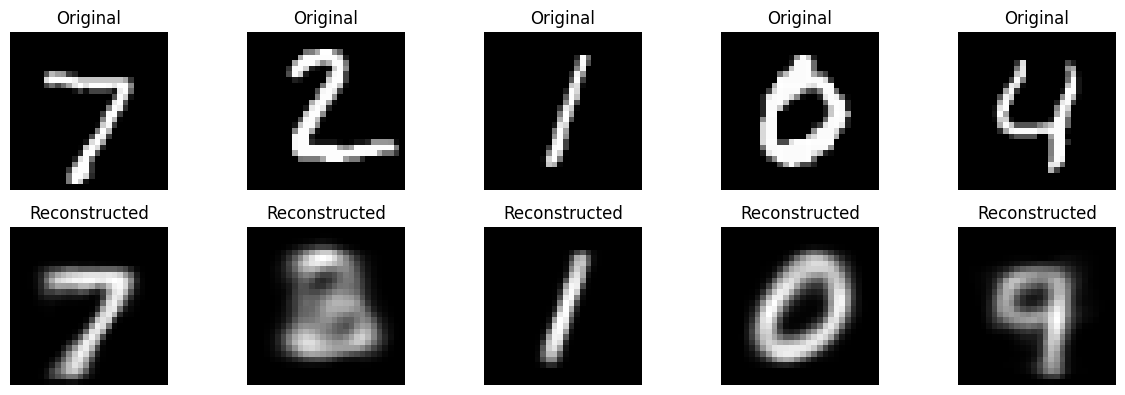

In [31]:
plt.figure(figsize=(12, 6))

for i in range(5):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_test_mnist[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.title("Original")

for i in range(5):
    plt.subplot(3, 5, i + 6)
    plt.imshow(x_test_reconstructed_mnist[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.title("Reconstructed")

plt.tight_layout()
plt.show()